# NARSS Prep: Land Cover Classification (ResNet-50) + NDVI Vegetation Mapping

Built as internship prep for NARSS (National Authority for Remote Sensing and
Space Sciences), Egypt.

**Before running:** In Kaggle, go to the right-hand **Settings** panel:
- Turn **Accelerator** to `GPU T4 x2` (or any available GPU)
- Turn **Internet** to `On` (needed to download EuroSAT / pretrained weights)

Two parts:
1. Fine-tune ResNet-50 on EuroSAT (10-class Sentinel-2 land cover benchmark)
2. Compute and visualize NDVI from Sentinel-2 Red/NIR bands


## 0. Setup

In [1]:
!pip install -q rasterio gradio

import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))


CUDA available: True
Device: cuda


## Part 1 — Land Cover Classification (EuroSAT + ResNet-50)

**Getting the data on Kaggle (recommended — more reliable than torchvision's direct download):**
1. Click **+ Add Input** (top right)
2. Search for `EuroSAT` in Kaggle Datasets (e.g. "EuroSAT: Land Use and Land Cover
   Classification with Sentinel-2") and add it
3. Update the `DATA_DIR` path below to match where Kaggle mounts it
   (usually `/kaggle/input/<dataset-folder-name>`)

If you'd rather let torchvision download it directly, keep `download=True`
and `Internet` must be On in notebook settings — this pulls from an external
host and is a bit less reliable on Kaggle's network than a Kaggle-hosted copy.


In [2]:
# ---- dataset_utils ----
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

EUROSAT_CLASSES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway", "Industrial",
    "Pasture", "PermanentCrop", "Residential", "River", "SeaLake",
]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def get_transforms(train: bool = True):
    resize_dim = 224
    if train:
        return transforms.Compose([
            transforms.Resize((resize_dim, resize_dim)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((resize_dim, resize_dim)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])


def get_eurosat_dataloaders(data_dir="/kaggle/working/data", batch_size=32,
                             val_split=0.15, test_split=0.15, num_workers=2,
                             download=True, seed=42):
    full_dataset = datasets.EuroSAT(root=data_dir, download=download,
                                     transform=get_transforms(train=True))

    n_total = len(full_dataset)
    n_val = int(n_total * val_split)
    n_test = int(n_total * test_split)
    n_train = n_total - n_val - n_test

    generator = torch.Generator().manual_seed(seed)
    train_set, val_set, test_set = random_split(
        full_dataset, [n_train, n_val, n_test], generator=generator)

    val_set.dataset.transform = get_transforms(train=False)
    test_set.dataset.transform = get_transforms(train=False)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return train_loader, val_loader, test_loader, EUROSAT_CLASSES


DATA_DIR = "/kaggle/working/data"  # change if using a Kaggle-hosted EuroSAT dataset instead
train_loader, val_loader, test_loader, classes = get_eurosat_dataloaders(
    data_dir=DATA_DIR, batch_size=32, download=True
)
print("Classes:", classes)
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)


Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Batch shape: torch.Size([32, 3, 224, 224])


In [3]:
# ---- model ----
import torch.nn as nn
from torchvision import models


def build_model(num_classes=10, freeze_backbone=False):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model(num_classes=len(classes), freeze_backbone=False).to(device)
print(model.fc)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s] 


Linear(in_features=2048, out_features=10, bias=True)


In [4]:
# ---- training loop ----
import time
import copy
import torch.optim as optim
from sklearn.metrics import classification_report


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return running_loss / total, running_correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, running_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return running_loss / total, running_correct / total, all_preds, all_labels


EPOCHS = 8
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2)

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f} | {elapsed:.1f}s")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_wts)
print(f"\nBest val accuracy: {best_val_acc:.4f}")


Epoch 1/8 | train_loss=0.3334 train_acc=0.9038 | val_loss=0.0696 val_acc=0.9765 | 226.3s
Epoch 2/8 | train_loss=0.0934 train_acc=0.9707 | val_loss=0.0779 val_acc=0.9741 | 233.5s
Epoch 3/8 | train_loss=0.0513 train_acc=0.9835 | val_loss=0.0579 val_acc=0.9807 | 234.4s
Epoch 4/8 | train_loss=0.0382 train_acc=0.9877 | val_loss=0.0579 val_acc=0.9802 | 234.4s
Epoch 5/8 | train_loss=0.0289 train_acc=0.9908 | val_loss=0.0700 val_acc=0.9793 | 235.2s
Epoch 6/8 | train_loss=0.0209 train_acc=0.9938 | val_loss=0.0946 val_acc=0.9701 | 235.4s
Epoch 7/8 | train_loss=0.0249 train_acc=0.9916 | val_loss=0.0845 val_acc=0.9753 | 235.4s
Epoch 8/8 | train_loss=0.0109 train_acc=0.9974 | val_loss=0.0563 val_acc=0.9837 | 235.3s

Best val accuracy: 0.9837


In [5]:
# ---- final test evaluation + save checkpoint ----
test_loss, test_acc, preds, labels = evaluate(model, test_loader, criterion, device)
print(f"Test accuracy: {test_acc:.4f}\n")
print(classification_report(labels, preds, target_names=classes))

import os
os.makedirs("/kaggle/working/models", exist_ok=True)
torch.save(model.state_dict(), "/kaggle/working/models/resnet50_eurosat.pt")
print("Saved model to /kaggle/working/models/resnet50_eurosat.pt")


Test accuracy: 0.9840

                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.96      0.97       472
              Forest       1.00      1.00      1.00       442
HerbaceousVegetation       0.98      0.99      0.98       458
             Highway       0.98      0.99      0.99       391
          Industrial       0.99      0.98      0.98       378
             Pasture       0.96      0.98      0.97       299
       PermanentCrop       0.98      0.97      0.97       379
         Residential       0.98      0.99      0.99       450
               River       0.99      0.99      0.99       375
             SeaLake       0.99      1.00      0.99       406

            accuracy                           0.98      4050
           macro avg       0.98      0.98      0.98      4050
        weighted avg       0.98      0.98      0.98      4050

Saved model to /kaggle/working/models/resnet50_eurosat.pt


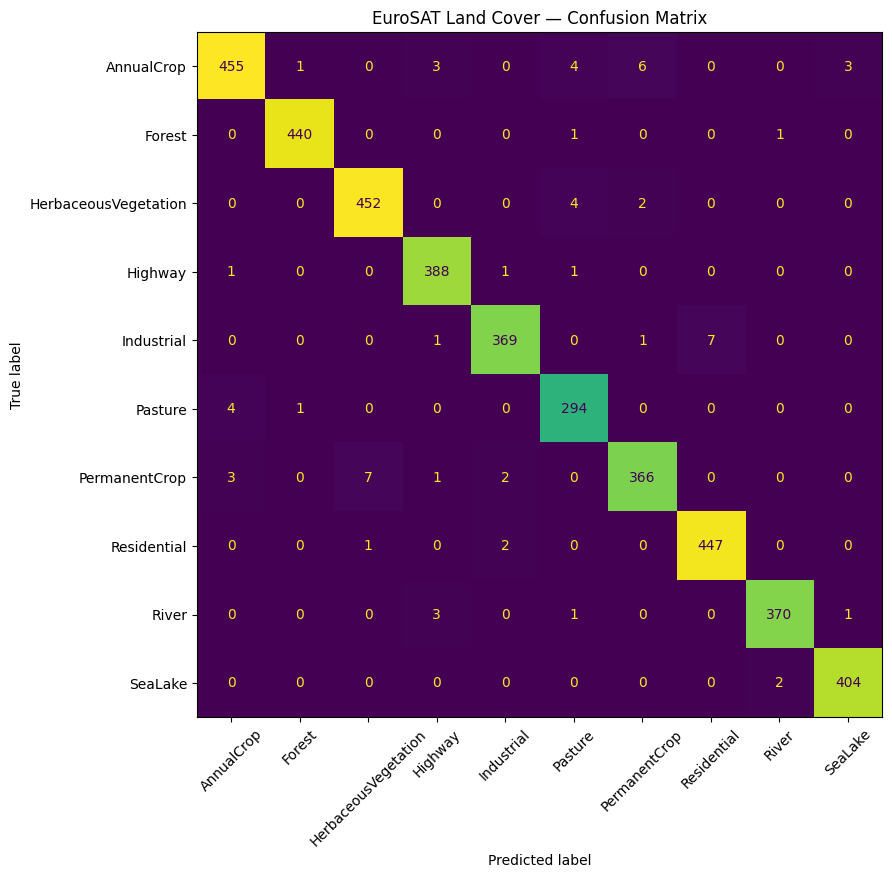

In [6]:
# ---- confusion matrix (screenshot-able result) ----
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay.from_predictions(labels, preds, display_labels=classes,
                                         xticks_rotation=45, ax=ax, colorbar=False)
plt.title("EuroSAT Land Cover — Confusion Matrix")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()


## Part 2 — NDVI Vegetation Mapping (real Sentinel-2 data)

**Getting a real tile over the Nile Delta:**
1. Go to the Copernicus Browser (browser.dataspace.copernicus.eu), free account
2. Search Sentinel-2 L2A scenes over the Nile Delta, pick a recent low-cloud date
3. Download **Band 4 (Red)** and **Band 8 (NIR)** as GeoTIFFs
4. On Kaggle: **+ Add Input → Upload** those two .tif files as a dataset
5. Update the paths below to point at them

Until you've uploaded real bands, the cell below runs on a synthetic
test scene so you can confirm the pipeline works end-to-end first.


mean_ndvi: 0.276
median_ndvi: 0.097
min_ndvi: -1.000
max_ndvi: 1.000
pct_water_or_bare: 55.085
pct_sparse_vegetation: 11.947
pct_dense_vegetation: 32.967


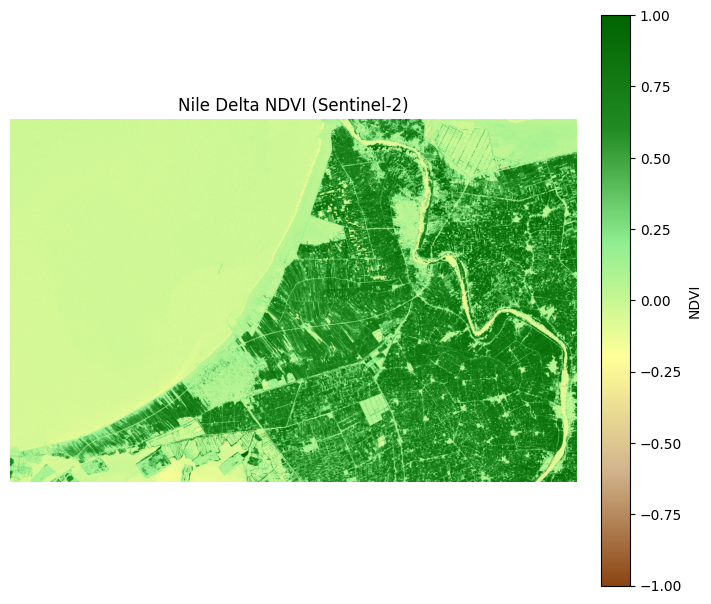

In [7]:
# ---- NDVI pipeline ----
import numpy as np
import rasterio
from matplotlib.colors import LinearSegmentedColormap


def load_bands(red_path, nir_path):
    with rasterio.open(red_path) as red_src:
        red = red_src.read(1).astype("float32")
        profile = red_src.profile
    with rasterio.open(nir_path) as nir_src:
        nir = nir_src.read(1).astype("float32")
    if red.shape != nir.shape:
        raise ValueError(f"Band shape mismatch: red={red.shape}, nir={nir.shape}")
    return red, nir, profile


def compute_ndvi(red, nir):
    np.seterr(divide="ignore", invalid="ignore")
    denominator = nir + red
    ndvi = np.where(denominator == 0, 0, (nir - red) / denominator)
    return np.clip(ndvi, -1, 1)


def ndvi_summary_stats(ndvi):
    valid = ndvi[~np.isnan(ndvi)]
    return {
        "mean_ndvi": float(np.mean(valid)),
        "median_ndvi": float(np.median(valid)),
        "min_ndvi": float(np.min(valid)),
        "max_ndvi": float(np.max(valid)),
        "pct_water_or_bare": float(np.mean(valid < 0.2) * 100),
        "pct_sparse_vegetation": float(np.mean((valid >= 0.2) & (valid < 0.5)) * 100),
        "pct_dense_vegetation": float(np.mean(valid >= 0.5) * 100),
    }


def plot_ndvi_heatmap(ndvi, title="NDVI Vegetation Health Map", save_path=None):
    ndvi_cmap = LinearSegmentedColormap.from_list(
        "ndvi_cmap", ["#8B4513", "#D2B48C", "#FFFF99", "#90EE90", "#228B22", "#006400"])
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(ndvi, cmap=ndvi_cmap, vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("NDVI")
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


# --- REPLACE these two paths once you've uploaded real Sentinel-2 bands ---
USE_REAL_DATA = True
RED_BAND_PATH = "/kaggle/input/datasets/mohamedalfatihomran/sentinel-2-l2a-tiff-32bit/2026-07-01-00_00_2026-07-01-23_59_Sentinel-2_L2A_B04_(Raw).tiff"
NIR_BAND_PATH = "/kaggle/input/datasets/mohamedalfatihomran/sentinel-2-l2a-tiff-32bit/2026-07-01-00_00_2026-07-01-23_59_Sentinel-2_L2A_B08_(Raw).tiff"

if USE_REAL_DATA:
    red, nir, profile = load_bands(RED_BAND_PATH, NIR_BAND_PATH)
    scene_title = "Nile Delta NDVI (Sentinel-2)"
else:
    np.random.seed(0)
    red = np.concatenate([np.random.uniform(0.15, 0.25, (100, 50)),
                           np.random.uniform(0.02, 0.08, (100, 50))], axis=1)
    nir = np.concatenate([np.random.uniform(0.15, 0.25, (100, 50)),
                           np.random.uniform(0.35, 0.55, (100, 50))], axis=1)
    scene_title = "Synthetic Test Scene NDVI (replace with real data above)"

ndvi = compute_ndvi(red, nir)
stats = ndvi_summary_stats(ndvi)
for k, v in stats.items():
    print(f"{k}: {v:.3f}")

plot_ndvi_heatmap(ndvi, title=scene_title, save_path="/kaggle/working/ndvi_map.png")
plt.show()


In [8]:
# sanity check: is water reading as strongly negative NDVI, as physics predicts?
print("Full-image Red mean:", red.mean(), "| Full-image NIR mean:", nir.mean())

# pick a patch you're confident is pure open sea from the image
# (top-left corner of your image = open Mediterranean water)
sea_patch_red = red[0:50, 0:50]
sea_patch_nir = nir[0:50, 0:50]
print("Open-sea patch — Red mean:", sea_patch_red.mean(), "| NIR mean:", sea_patch_nir.mean())
print("Open-sea patch NDVI:", ((sea_patch_nir.mean() - sea_patch_red.mean()) / (sea_patch_nir.mean() + sea_patch_red.mean())))

Full-image Red mean: 0.10472247 | Full-image NIR mean: 0.21800639
Open-sea patch — Red mean: 0.09082848 | NIR mean: 0.0881162
Open-sea patch NDVI: -0.015157084


## Outputs to screenshot / show your team lead

- `/kaggle/working/confusion_matrix.png` — classifier performance across all 10 classes
- `/kaggle/working/ndvi_map.png` — vegetation health heatmap
- `/kaggle/working/models/resnet50_eurosat.pt` — trained model weights (download from Kaggle's Output tab)

Next: swap in a real Nile Delta Sentinel-2 tile (`USE_REAL_DATA = True` above)
once you've uploaded the bands, and re-run that cell.
